In [1]:
#Tratamiento de datos 
import numpy as np 
import pandas as pd 

#Graficos 
import matplotlib.pyplot as plt

#Prepocesado y modelo 
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA


In [2]:
#Paso 1: Extraer datos iris
url = "https://gist.githubusercontent.com/netj/8836201/raw/iris.csv"
df = pd.read_csv(url)
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
#Separar columnas de texto 
X = df.drop(columns=['variety'])
X

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
#Contar renglones 
renglones = len(X.index)
renglones

150

In [5]:
#Estandarizar 
X2 = StandardScaler().fit_transform(X)
X2

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [6]:
#Matriz de correlaciones 
A = (1/renglones) * np.dot(X2.T, X2)
A

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [7]:
#Entrenar al PCA
pca = PCA()
pca.fit(X2)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [8]:
#Eigenvalores
from numpy import linalg as LA 
print("Eigenvalores:")
print(LA.eigvals(A))

Eigenvalores:
[2.91849782 0.91403047 0.14675688 0.02071484]


In [18]:
# Porcentaje de varianza explicada por cada componente
print("Porcentaje de varianza explicada por componente")
print(pca.explained_variance_ratio_)

# Sumamos los dos primeros (PC1 + PC2)
varianza_2pc = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]
print(f"\nVarianza explicada por PC1 + PC2: {varianza_2pc*100:.2f}%")

Porcentaje de varianza explicada por componente
[0.72962445 0.22850762 0.03668922 0.00517871]

Varianza explicada por PC1 + PC2: 95.81%


In [10]:
#Eigenvectores
pd.DataFrame(data = pca.components_,
             columns = X.columns,
             index = ['PC1','PC2','PC3','PC4'])

,sepal.length,sepal.width,petal.length,petal.width
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942
PC3,0.719566,-0.244382,-0.142126,-0.634273
PC4,-0.261286,0.123510,0.801449,-0.523597


In [11]:
#Proyecciones
proyecciones = np.dot(pca.components_, X2.T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1','PC2','PC3','PC4'])
proyecciones = proyecciones.transpose()
proyecciones

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


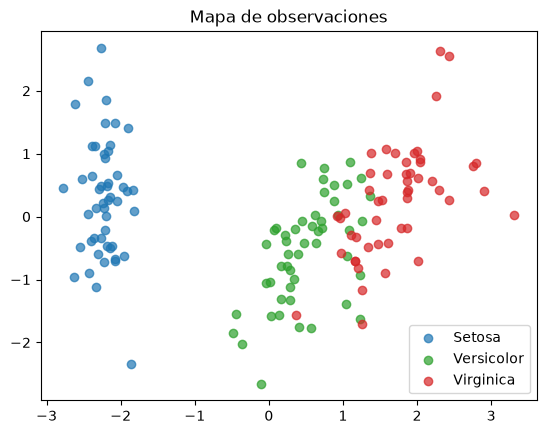

In [19]:
#Mapa de observaciones (coloreado por especie)
x = proyecciones.iloc[:,0].to_numpy()
y = proyecciones.iloc[:,1].to_numpy()

colores = {'Setosa': 'tab:blue', 'Versicolor': 'tab:green', 'Virginica': 'tab:red'}

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")

for especie_nombre, color in colores.items():
    mask = (df['variety'] == especie_nombre).to_numpy()
    ax.scatter(x[mask], y[mask], label=especie_nombre, color=color, alpha=0.7)

ax.legend()
plt.show()

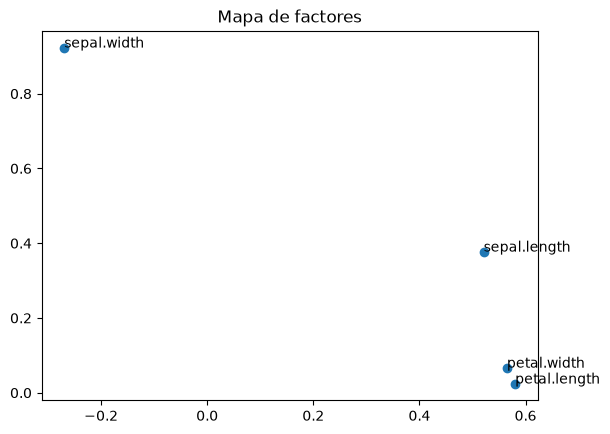

In [14]:
#Mapa de factores 
componentes_2 = pd.DataFrame(data = pca.components_,
                              columns = X.columns,
                              index = ['PC1','PC2','PC3','PC4'])
componentes_2 = componentes_2.iloc[0:2,:].T

x = componentes_2.iloc[:,0].to_numpy()
y = componentes_2.iloc[:,1].to_numpy()
z = componentes_2.index

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x, y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

plt.show()

In [16]:
# Le pegamos las proyecciones al índice original para poder compararlas
proyecciones.index = df.index

# Los 3 casos con PC1 mas bajo
casos_bajo = proyecciones.sort_values(by='PC1').head(3).index

# Los 3 casos con PC1 mas alto
casos_alto = proyecciones.sort_values(by='PC1', ascending=False).head(3).index

print("Casos con PC1 mas bajo:")
print(df.loc[casos_bajo])

print("\nCasos con PC1 mas alto:")
print(df.loc[casos_alto])

Casos con PC1 mas bajo:
    sepal.length  sepal.width  petal.length  petal.width variety
22           4.6          3.6           1.0          0.2  Setosa
13           4.3          3.0           1.1          0.1  Setosa
32           5.2          4.1           1.5          0.1  Setosa

Casos con PC1 mas alto:
     sepal.length  sepal.width  petal.length  petal.width    variety
118           7.7          2.6           6.9          2.3  Virginica
122           7.7          2.8           6.7          2.0  Virginica
135           7.7          3.0           6.1          2.3  Virginica
